# Imports der Bibliotheken

In [1]:
#Masterprojekt SFH - 1 Verbraucher, 1 Wärmepumpe, 1 Speicher
import logging
logger = logging.getLogger("gurobipy")
logger.propagate = False

import pandas as pd
import pypsaheat as ph
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Einlesen Lastgänge & Zuordnung der Daten

In [2]:
#Einlesen der Lastgänge
input_data = pd.read_csv('Inputs/MasterProjekt_Lastprofile.csv', index_col=0)
input_data

#limitieren der Daten auf 3 Wochen
start = 0      # 0 = Anfang des Jahres
input_data = input_data.iloc[start : start + 504]
input_data.index = range(len(input_data)) 

In [3]:
input_data = input_data.drop(columns=["Waerme gesamt (kW)"]).rename(
    columns={"Temp C": "temp","Zone 2-Trinkwarmwasser (kW)": "heat_water","Zone 2-Raumwaerme (kW)": "heat_space",}
)

print(input_data.columns)
input_data = input_data[["temp", "heat_water", "heat_space"]]
input_data.index.name = "index"
input_data.to_csv("Inputs/load_profile_3_weeks.csv", index=True)

Index(['heat_space', 'heat_water', 'temp'], dtype='object')


In [4]:
input_data

,temp,heat_water,heat_space
index,,,
0,6.286,0.2,1.7
1,5.997,0.1,1.7
2,5.705,0.1,1.8
3,5.534,0.0,1.7
4,5.451,0.1,1.8
...,...,...,...
499,-4.842,0.8,5.8
500,-5.690,0.7,5.8
501,-6.235,0.6,5.6


<Axes: xlabel='index'>

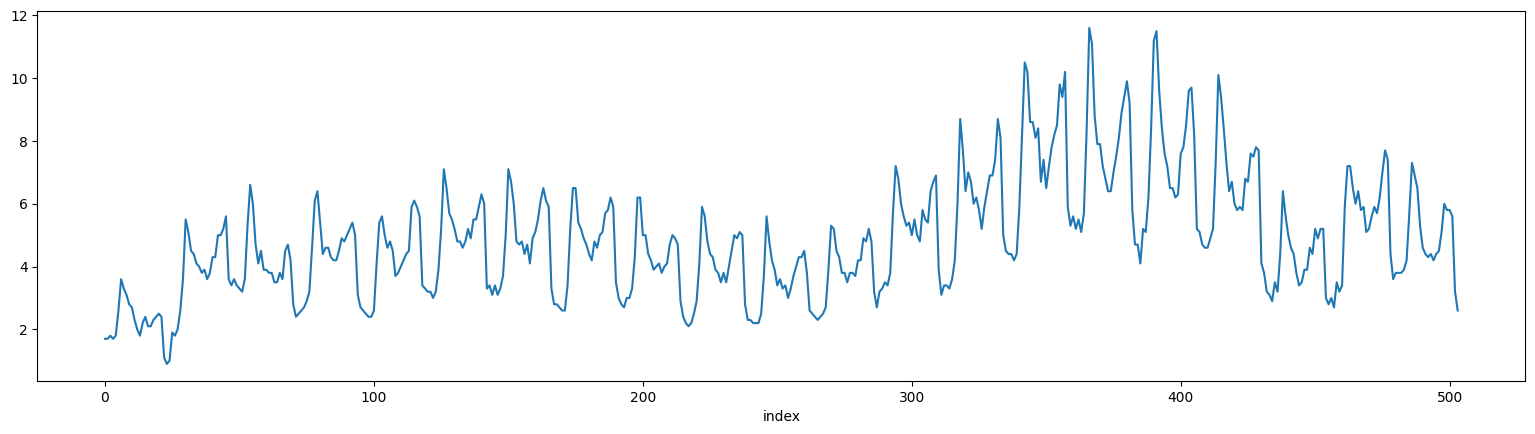

In [5]:
#Zuordnung der Daten aus den Lastgängen
raumwaerme = input_data['heat_space'] #Heizlast von SFH in kW
raumwaerme.plot(figsize=(19.2, 4.8))

<Axes: xlabel='index'>

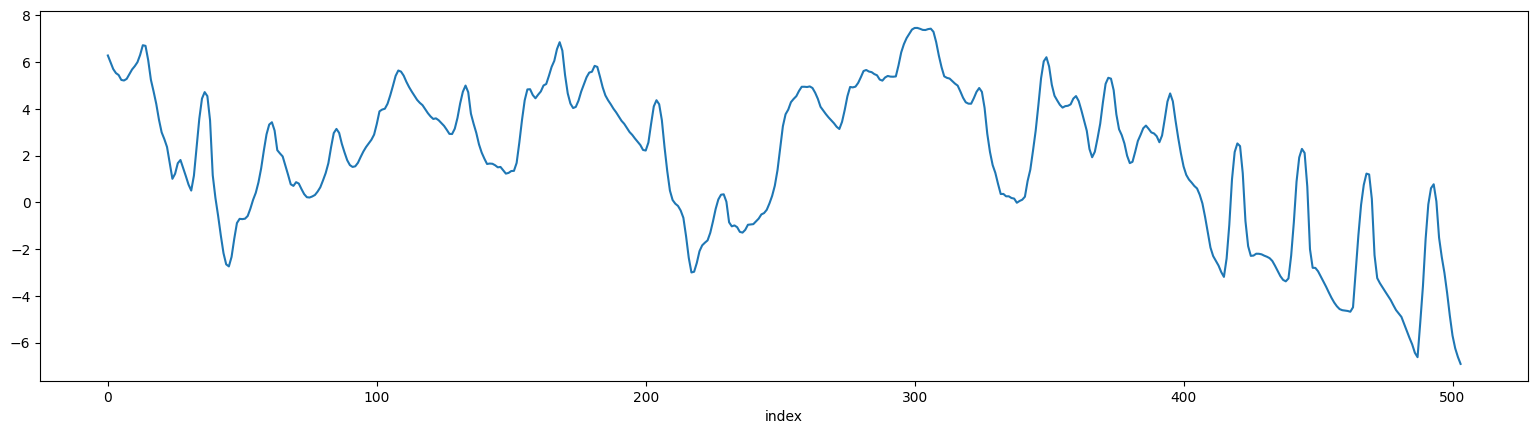

In [6]:
# aussentemperatur = df_data_weather['DE_temperature']
aussentemperatur = input_data['temp']
aussentemperatur.plot(figsize=(19.2, 4.8))

# System Eigenschaften

In [7]:
#Wärmespeicher Eigenschaften 
Store_height = 2 #m
Store_base = 0.8 #m²
V_layer = (Store_height * Store_base) / 3

T_Warmwasser = 55

#Wärmepumpen Leistung
HP_power = 20 #kW Wärmepumpenleistung

#Strom
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug
grid_power = np.inf #kW Hausanschluss Leistung

In [8]:
V_layer

0.5333333333333333

<Axes: xlabel='index'>

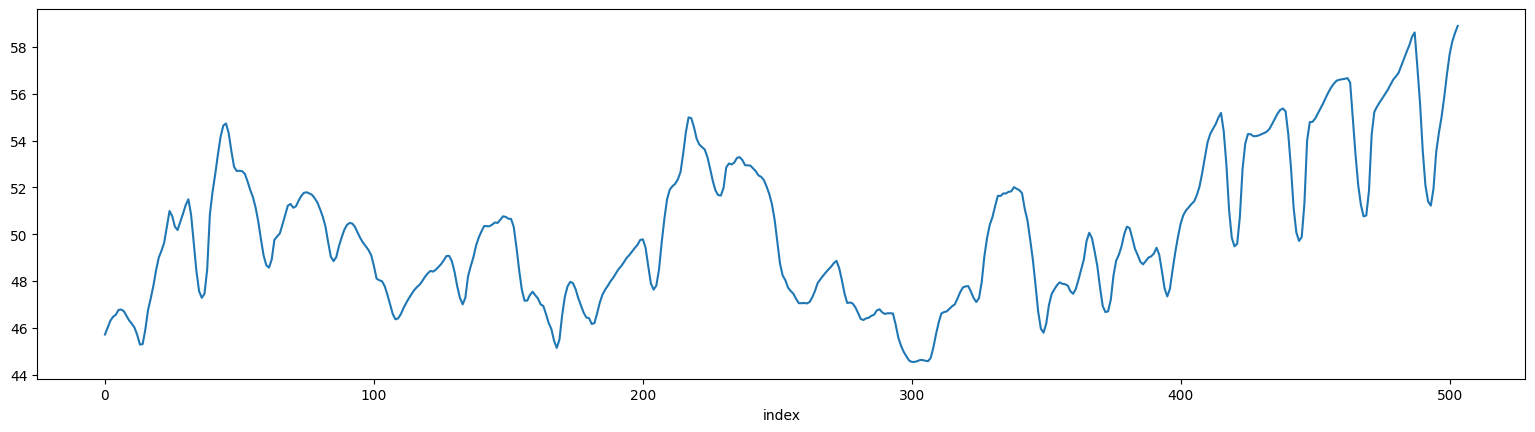

In [9]:
# Vorlauftemperatur für Heizsystem
T_at_0 = 52  #°C Vorlauftemperatur bei Außentemperatur 0°C
T_gradient = 1  #°C/°C Steigung der Heizkurve

T_flow = ph.physics.flow_temperature(T_at_0, T_gradient, aussentemperatur)
T_flow.plot(figsize=(19.2, 4.8))

In [10]:
# Berechnung der Rücklauftemperatur

t_flow_return = T_flow - 10
t_flow_return

index
0      35.71
1      36.00
2      36.30
3      36.47
4      36.55
       ...  
499    46.84
500    47.69
501    48.24
502    48.60
503    48.90
Name: T_flow, Length: 504, dtype: float64

# Modellerstellung

In [11]:
# Aufbau des Modells
n = ph.HeatNetwork()
n.set_snapshots(input_data.index)

n.add("Bus",  
      name = "electricity"      
)

n.add('Generator',
      bus = 'electricity',
      name = 'grid',
      p_nom = grid_power,
      marginal_cost = grid_cost
  )

n.add('Load', 
      bus = 'electricity', 
      name = 'Elektrische Last'
)

# Hinzufügen der Raumwärmelast
n.add('HeatLoad',
      name = 'heat_space_demand',
      heat_store = 'hs',
      p_set = input_data['heat_space'],
      T_demand = T_flow
      )

# Hinzufügen eines Schichtspeichers mit konstanten Volumschichten
n.add('HeatStore',
      name='hs',
      constant='temperature',  # konstante Temperatur in den Schichten
      height=Store_height,
      base=Store_base,      
      cyclic=False,
      U_wall=0.15,
      V_initial = [V_layer, V_layer, V_layer],  # Volumen in den Schichten m³                 
      T_layer = [60,55,50],  # Beispieltemperaturen für die Schichten
      T_return = t_flow_return # Rücklauftemperatur des Heizsystems, °C
)

# Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp',
      bus0 = 'electricity',
      p_nom = HP_power,
      heat_store = 'hs',
      T_source = input_data['temp'],
      T_max = 65,        # max. lieferbare Temperatur der WP
      #T_sink = T_at_0,  
      heat_source = 'air'
)

In [12]:
n.heat_loads

attribute,heat_store,carrier,type,p_set,T_demand,T_diff_return,internal_exchange,outlet_height,inlet_height
HeatLoad,,,,,,,,,
heat_space_demand,hs,,,0.0,50.0,10.0,False,1.0,0.0


# Optimierung

In [13]:
n.heat_stores_t

{'T_amb': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'T_return': HeatStore     hs
 snapshot        
 0          35.71
 1          36.00
 2          36.30
 3          36.47
 4          36.55
 ...          ...
 499        46.84
 500        47.69
 501        48.24
 502        48.60
 503        48.90
 
 [504 rows x 1 columns],
 'T': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,

In [14]:
# Optimierung mit rollierendem Horizont
#Langfristig 3 Woche Modellierung
n.optimize.optimize_with_rolling_horizon(horizon = 24, overlap = 12)

INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [0:23] (1/42).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2756558
Academic license - for non-commercial use only - expires 2026-12-18


INFO:linopy.io: Writing time: 0.03s


Read LP format model from file C:\Users\robin\AppData\Local\Temp\linopy-problem-vg6o3xsx.lp
Reading time = 0.01 seconds
obj: 576 rows, 240 columns, 1029 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 245K, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 576 rows, 240 columns and 1029 nonzeros
Model fingerprint: 0xaa57184d
Coefficient statistics:
  Matrix range     [4e-01, 3e+01]
  Objective range  [3e-01, 3e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-03, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 460 rows and 52 columns
Presolve time: 0.00s
Presolved: 116 rows, 188 columns, 458 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   9.005260e+00   0.000000e+00      0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 576 duals
Objective: 2.53e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-fix-layer-upper, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [12:35] (2/42).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


...

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 576 duals
Objective: 2.24e+01
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-fix-layer-upper, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [492:503] (42/42).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2756558
Academic license - for non-commercial use only - expires 2026-12-18


INFO:linopy.io: Writing time: 0.02s


Read LP format model from file C:\Users\robin\AppData\Local\Temp\linopy-problem-rmo4o8pf.lp
Reading time = 0.01 seconds
obj: 288 rows, 120 columns, 513 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 245K, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 288 rows, 120 columns and 513 nonzeros
Model fingerprint: 0xe1260cfd
Coefficient statistics:
  Matrix range     [4e-01, 2e+01]
  Objective range  [3e-01, 3e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-03, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 232 rows and 28 columns
Presolve time: 0.00s
Presolved: 56 rows, 92 columns, 230 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   8.664080e+00   0.000000e+00      0s
    

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 120 primals, 288 duals
Objective: 8.75e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-fix-layer-upper, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.


In [15]:
#Zuordnung der Ergebnisse
m = n.optimize.create_model()

Index(['electricity'], dtype='object', name='Bus')


In [16]:
#Inhalte der Optimierung
m

Linopy MILP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * HeatStore-hs-V_layer (snapshot, layer)
 * HeatStore-hs-p_internal (snapshot, layer)
 * HeatPump-status (snapshot, HeatPump)
 * HeatPump-hp-p (snapshot, layer)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Bus-nodal_balance (Bus, snapshot)
 * HeatStore-hs-fix-volume-upper (snapshot)
 * HeatStore-hs-fix-volume-lower (snapshot, layer)
 * HeatStore-hs-fix-layer-upper (snapshot, layer)
 * HeatStore-hs-layer_balance (snapshot, layer)
 * HeatStore-hs-internal-lower (snapshot, layer)
 * HeatPump-hp-fix-p-lower (snapshot)
 * HeatPump-hp-fix-p-upper (snapshot)
 * HeatPump-hp-fix-p-layer-lower (snapshot, layer)
 * HeatPump-hp-fix-p-layer-upper (snapshot, layer)

Status:
-------
initialized

In [17]:
n.heat_pumps_t

{'T_source':              hp
 snapshot       
 0         6.286
 1         5.997
 2         5.705
 3         5.534
 4         5.451
 ...         ...
 499      -4.842
 500      -5.690
 501      -6.235
 502      -6.605
 503      -6.903
 
 [504 rows x 1 columns],
 'T_nom': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'p_min_pu': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 5

In [18]:
heatstore_daten=n.heat_stores_t.T

In [19]:
n.heat_stores_t

{'T_amb': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'T_return': HeatStore     hs
 snapshot        
 0          35.71
 1          36.00
 2          36.30
 3          36.47
 4          36.55
 ...          ...
 499        46.84
 500        47.69
 501        48.24
 502        48.60
 503        48.90
 
 [504 rows x 1 columns],
 'T': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,

# Python Ergebnisse

In [20]:
#Zuordnung der Ergebnisse aus dem Modell
#WP-Daten und Schichtdaten
v_hs_60 = n.heat_stores_t.V.iloc[:, 0]
v_hs_55 = n.heat_stores_t.V.iloc[:, 1]
v_hs_50 = n.heat_stores_t.V.iloc[:, 2]
T_return = n.heat_stores_t.T_return


p_elec = n.heat_pumps_t.p_elec
p_heat = n.heat_pumps_t.p_heat
COP = n.heat_pumps_t.COP
p_hp_60 = p_heat.hp.iloc[:,0]
p_hp_55 = p_heat.hp.iloc[:,1]
p_hp_50 = p_heat.hp.iloc[:,2]

<Axes: xlabel='snapshot'>

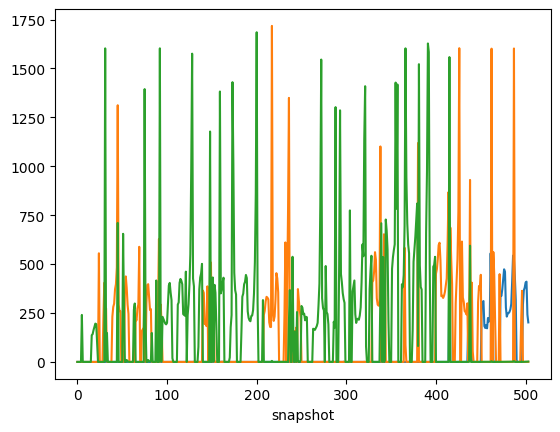

In [21]:
# Berechnung der Massenströme pro Schicht
m_hs_60 = p_hp_60 / ((0.001161388889) * (60 - T_return.hs))
m_hs_55 = p_hp_55 / ((0.001161388889) * (55 - T_return.hs))
m_hs_50 = p_hp_50 / ((0.001161388889) * (50 - T_return.hs))

m_hs_60.plot() 
m_hs_55.plot()
m_hs_50.plot()


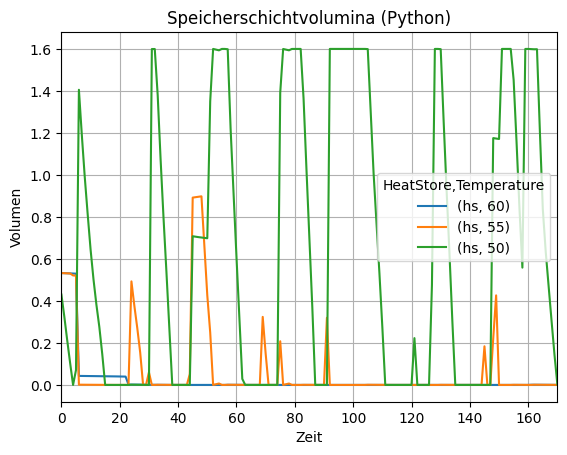

In [22]:
n.heat_stores_t.V.plot()
plt.title('Speicherschichtvolumina (Python)')
plt.xlabel('Zeit')
plt.ylabel('Volumen')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher/py_speicherschichten.png')
plt.show()


In [23]:
# Berechnung der Kosten für den Netzbezug durch die Wärmepumpe
cost_grid = p_elec * grid_cost
total_cost_grid = cost_grid.sum().sum()

print(f"Kosten Netzbezug durch WP: {total_cost_grid:.2f} €")

Kosten Netzbezug durch WP: 362.73 €


# TRNSYS Ergebnisse

In [24]:
TRNSYSinputs = [
    "Inputs/TRNSYS/TRNSYSMassenstromHausseitig.csv",
    "Inputs/TRNSYS/TRNSYSRaumwärmebedarf.csv",
    "Inputs/TRNSYS/TRNSYSRücklauftemperaturKonstanterTemperaturspeicher.csv",
    "Inputs/TRNSYS/TRNSYSspeichermitteltemperaturKonstanterTemperaturspeicher.csv",
    #"Inputs/TRNSYS/TRNSYSspeicherschichttemperaturen.csv",
    "Inputs/TRNSYS/TRNSYSWärmepumpe.csv"
]

df_liste = []

for f in TRNSYSinputs:
    df = pd.read_csv(f, encoding='latin1', skipinitialspace=True, engine='python', quoting=3, sep=',')
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    if 'TIME' in df.columns:
        df = df[pd.to_numeric(df['TIME'], errors='coerce').notnull()]
        df = df.apply(pd.to_numeric, errors='coerce')
        df['TIME'] = df['TIME'].round(2)
        df = df.set_index('TIME')
    
    df_liste.append(df)

TRNSYSdata = pd.concat(df_liste, axis=1).sort_index().reset_index()
TRNSYSdata = TRNSYSdata.rename(columns={'TIME':'Time', 'Massenstrom':'ts_m_heatspace', 'T_amb':'ts_T_amb', 'P_heatspace':'ts_P_heatspace', 'T_R':'ts_T_R', 'T_M':'ts_T_m', 'T_1':'ts_T_1', 'T_2':'ts_T_2','T_3':'ts_T_3', 'p_heat':'ts_P_heat', 'm_flow':'ts_m_flow'})
TRNSYSdata = TRNSYSdata.round(6)
TRNSYSdata

,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_P_heat,ts_m_flow
0,2112.0,195.627840,-2.620,2.272,49.885,30.000000,11.766,700.0
1,2113.0,201.138484,-3.313,2.336,52.173,58.109656,8.448,700.0
2,2114.0,208.026788,-3.869,2.416,50.730,56.255813,0.000,0.0
3,2115.0,221.803396,-4.301,2.576,52.612,59.800088,7.062,700.0
4,2116.0,256.244917,-4.747,2.976,51.111,57.578383,0.000,0.0
...,...,...,...,...,...,...,...,...
163,2275.0,236.957666,13.508,2.752,36.732,40.142000,0.000,0.0
164,2276.0,224.558718,11.191,2.608,35.263,39.253237,0.000,0.0
165,2277.0,197.005501,10.786,2.288,34.001,38.328127,0.000,0.0
166,2278.0,137.766085,10.258,1.600,33.126,37.606006,0.000,0.0


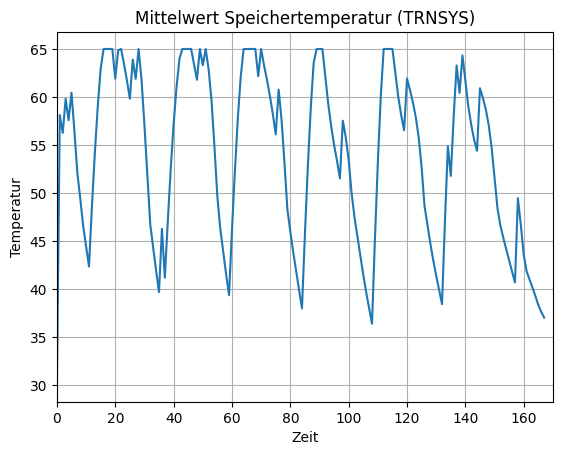

In [25]:
TRNSYS_T_m = TRNSYSdata['ts_T_m'].copy()

TRNSYS_T_m.plot()
plt.title('Mittelwert Speichertemperatur (TRNSYS)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher/ts_speicherschichten_m.png')
plt.show()

# CSV-Ausgabe

In [26]:
# Kombinierten DataFrame erstellen
output_pypsa = pd.DataFrame({
    'py_P_elec': p_elec.hp,
    'py_P_heat_60': p_heat[('hp', 60)],
    'py_P_heat_55': p_heat[('hp', 55)],
    'py_P_heat_50': p_heat[('hp', 50)],
    'py_m_hs_60': m_hs_60,
    'py_m_hs_55': m_hs_55,
    'py_m_hs_50': m_hs_50,
    'py_COP_60': COP[('hp', 60)],
    'py_COP_55': COP[('hp', 55)],
    'py_COP_50': COP[('hp', 50)],
    'py_V_60': v_hs_60,
    'py_V_55': v_hs_55,
    'py_V_50': v_hs_50,
    'py_V_total':  v_hs_60 + v_hs_55 + v_hs_50,
    'py_T_return': T_return.hs,
    'py_P_heat_total': p_heat[('hp', 60)] + p_heat[('hp', 55)] + p_heat[('hp', 50)]
})


output_pypsa.to_csv(
    "Outputs/konstanterTemperaturspeicher/output_pypsa.csv",
    sep=",",
    index_label="index", 
    float_format="%.3f"     
)


In [27]:
output_combined = pd.concat([output_pypsa, TRNSYSdata], axis=1)
output_combined

,py_P_elec,py_P_heat_60,py_P_heat_55,py_P_heat_50,py_m_hs_60,py_m_hs_55,py_m_hs_50,py_COP_60,py_COP_55,py_COP_50,...,py_T_return,py_P_heat_total,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_P_heat,ts_m_flow
0,0.000000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,2.13,2.41,2.72,...,35.71,0.0000,2112.0,195.627840,-2.620,2.272,49.885,30.000000,11.766,700.0
1,0.000000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,2.11,2.39,2.71,...,36.00,0.0000,2113.0,201.138484,-3.313,2.336,52.173,58.109656,8.448,700.0
2,0.000000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,2.10,2.38,2.69,...,36.30,0.0000,2114.0,208.026788,-3.869,2.416,50.730,56.255813,0.000,0.0
3,0.000000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,2.09,2.37,2.68,...,36.47,0.0000,2115.0,221.803396,-4.301,2.576,52.612,59.800088,7.062,700.0
4,0.000000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,2.08,2.36,2.67,...,36.55,0.0000,2116.0,256.244917,-4.747,2.976,51.111,57.578383,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,3.607162,5.8032,0.0028,0.0024,379.694229,0.295454,0.653953,1.61,1.83,2.07,...,46.84,5.8084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
500,3.675658,5.8032,0.0028,0.0024,405.911946,0.329809,0.894585,1.58,1.79,2.03,...,47.69,5.8084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
501,3.594586,5.6032,0.0028,0.0024,410.252398,0.356643,1.174143,1.56,1.76,2.00,...,48.24,5.6084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
502,2.069393,3.2032,0.0028,0.0024,241.936584,0.376704,1.476065,1.55,1.75,1.98,...,48.60,3.2084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
output_combined_ordered = output_combined.iloc[:, [ 13, 17, 18, 19, 20, 16, 15, 14, 11,10,12, 0, 1, 4, 7, 2, 5, 8, 3, 6, 9]]
output_combined_ordered.to_csv(
    "Outputs/konstanterTemperaturspeicher/output_combined_ordered.csv",
    sep=",",
    index_label="index", 
    float_format="%.3f"     
)
output_combined_ordered

,py_V_total,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,Time,py_P_heat_total,py_T_return,py_V_55,py_V_60,...,py_P_elec,py_P_heat_60,py_m_hs_60,py_COP_60,py_P_heat_55,py_m_hs_55,py_COP_55,py_P_heat_50,py_m_hs_50,py_COP_50
0,1.495778,195.627840,-2.620,2.272,49.885,2112.0,0.0000,35.71,0.532714,0.532771,...,0.000000,0.0000,0.000000,2.13,0.0000,0.000000,2.41,0.0000,0.000000,2.72
1,1.389521,201.138484,-3.313,2.336,52.173,2113.0,0.0000,36.00,0.532085,0.532202,...,0.000000,0.0000,0.000000,2.11,0.0000,0.000000,2.39,0.0000,0.000000,2.71
2,1.274791,208.026788,-3.869,2.416,50.730,2114.0,0.0000,36.30,0.531447,0.531626,...,0.000000,0.0000,0.000000,2.10,0.0000,0.000000,2.38,0.0000,0.000000,2.69
3,1.165111,221.803396,-4.301,2.576,52.612,2115.0,0.0000,36.47,0.530804,0.531047,...,0.000000,0.0000,0.000000,2.09,0.0000,0.000000,2.37,0.0000,0.000000,2.68
4,1.051794,256.244917,-4.747,2.976,51.111,2116.0,0.0000,36.55,0.521328,0.530467,...,0.000000,0.0000,0.000000,2.08,0.0000,0.000000,2.36,0.0000,0.000000,2.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.000000,NaN,NaN,NaN,NaN,NaN,5.8084,46.84,0.000000,0.000000,...,3.607162,5.8032,379.694229,1.61,0.0028,0.295454,1.83,0.0024,0.653953,2.07
500,0.000000,NaN,NaN,NaN,NaN,NaN,5.8084,47.69,0.000000,0.000000,...,3.675658,5.8032,405.911946,1.58,0.0028,0.329809,1.79,0.0024,0.894585,2.03
501,0.000000,NaN,NaN,NaN,NaN,NaN,5.6084,48.24,0.000000,0.000000,...,3.594586,5.6032,410.252398,1.56,0.0028,0.356643,1.76,0.0024,1.174143,2.00
502,0.000000,NaN,NaN,NaN,NaN,NaN,3.2084,48.60,0.000000,0.000000,...,2.069393,3.2032,241.936584,1.55,0.0028,0.376704,1.75,0.0024,1.476065,1.98


# Combined Plots

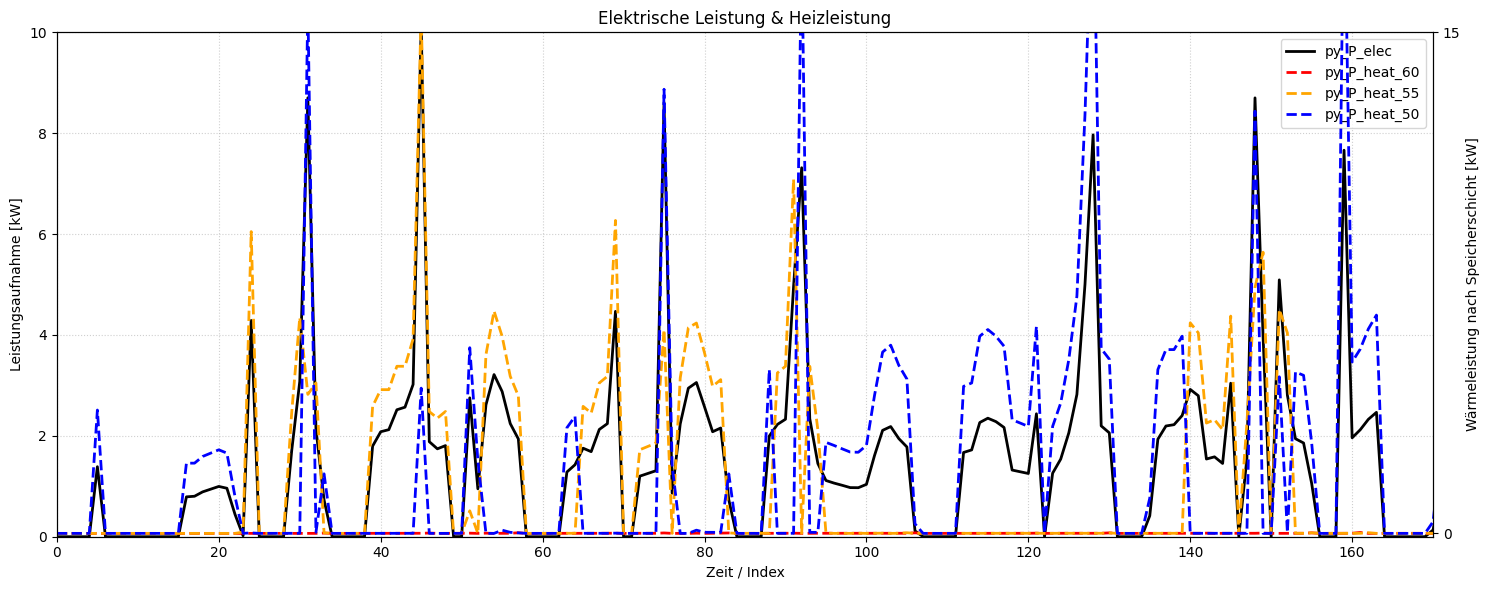

In [31]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_P_elec'], label='py_P_elec', linewidth=2, color='black')
#ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=2, color='dodgerblue')

ax1.set_title('Elektrische Leistung & Heizleistung')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Leistungsaufnahme [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0, 10) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_60'], label='py_P_heat_60', linewidth=2, color='red', linestyle='--')
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_55'], label='py_P_heat_55', linewidth=2, color='orange', linestyle='--')
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_50'], label='py_P_heat_50', linewidth=2, color='blue', linestyle='--')

ax2.set_ylabel('Wärmeleistung nach Speicherschicht [kW]')
ax2.set_ylim(-0.1, 1.1) # Etwas Puffer nach oben/unten, damit man die Linie besser sieht
ax2.set_yticks([0, 15])  # Nur 0 und 1 anzeigen

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Elektrische Leistung & Heizleistung.png')
plt.show()

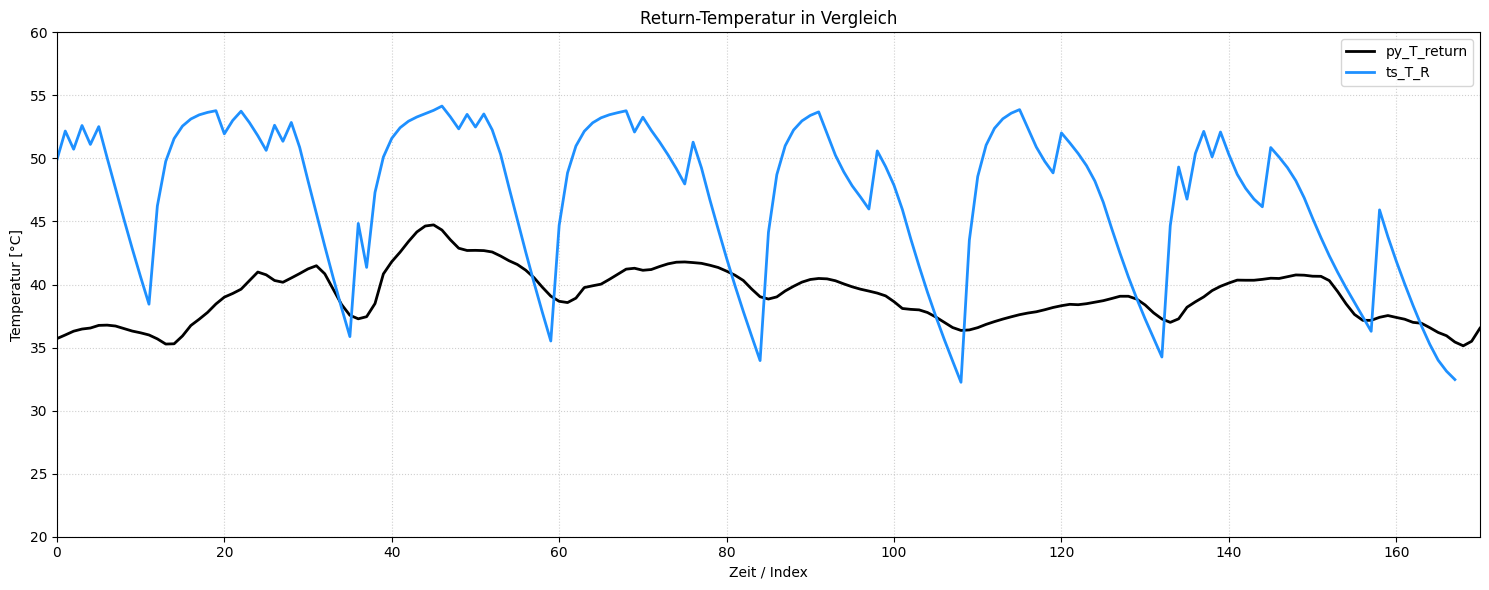

In [32]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_T_return'], label='py_T_return', linewidth=2, color='black')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_R'], label='ts_T_R', linewidth=2, color='dodgerblue')

ax1.set_title('Return-Temperatur in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur [°C]')
ax1.set_xlim(0, 170)
ax1.set_ylim(20,60) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Rücklauftemperatur im Vergleich.png')
plt.show()

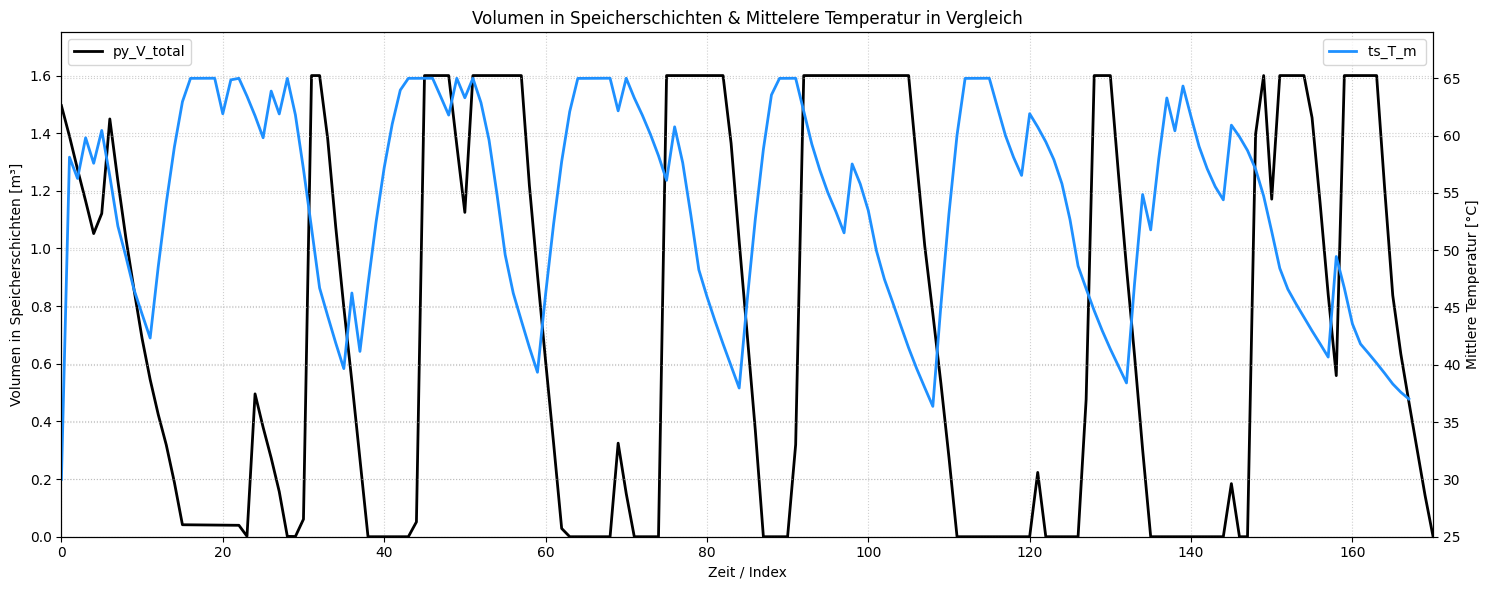

In [33]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_V_total'], label='py_V_total', linewidth=2, color='black')

ax1.set_title('Volumen in Speicherschichten & Mittelere Temperatur in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Volumen in Speicherschichten [m³]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0,1.75) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Rechte y-Achse: Temperaturen ---
ax2 = ax1.twinx()
ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='ts_T_m ', linewidth=2, color='dodgerblue')

ax2.set_xlabel('Zeit / Index')
ax2.set_ylabel('Mittlere Temperatur [°C]')
ax2.set_xlim(0, 170)
ax2.set_ylim(25,69) # Beispielhafter Bereich für Temperaturen
ax2.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper left')
ax2.legend(lines2, labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Volumen und Mittlere Temperatur im Vergleich.png')
plt.show()

KeyError: 'ts_P_heat'

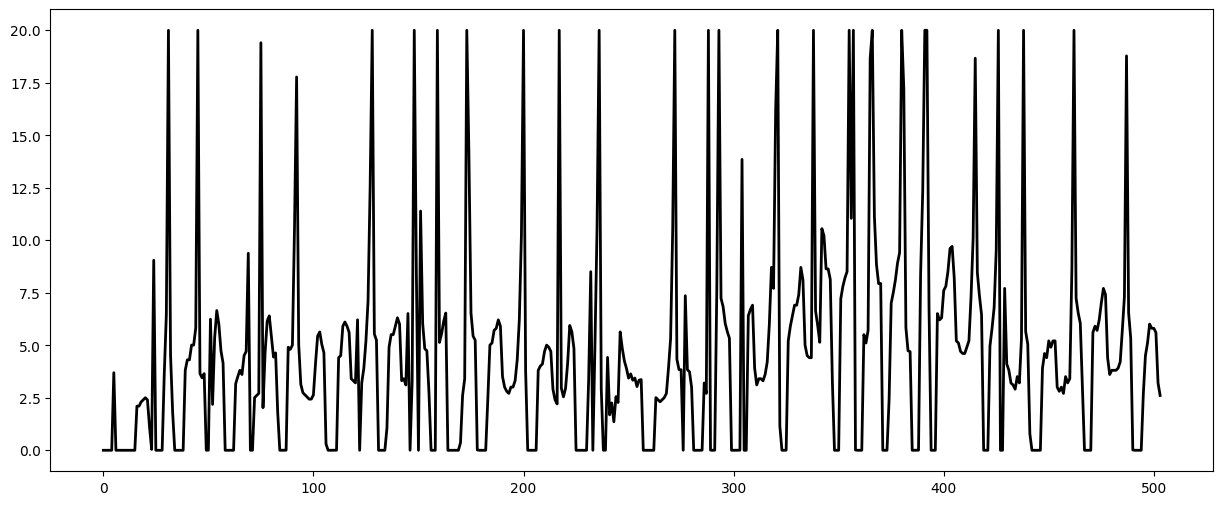

In [34]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_P_heat_total'], label='py_P_heat_total', linewidth=2, color='black')
ax1.plot(output_pypsa.index,output_combined_ordered['ts_P_heat'], label='ts_P_heat', linewidth=2, color='dodgerblue')

ax1.set_title('Heizleistung in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Heizleistung [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0,20) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Heizleistung in Vergleich.png')

plt.show()

In [ ]:
# Erstelle Figur und Achsen
from numpy import test


fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot((output_combined_ordered['py_P_heat_total'] - output_combined_ordered['ts_P_heat']), label='Differenz zwischen den Heizleistungen', linewidth=2, color='black')


ax1.set_title('Differenz zwischen den Heizleistungen')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Heizleistung [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(-20,20) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Differenz zwischen den Heizleistungen.png')
plt.show()

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plotten der Temperaturen beider Datenquellen auf ax1
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='T_m Python', linewidth=1.5)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Kombinierte Daten: Temperaturen und Leistungen')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.grid(True)

# Rechte y-Achse: Leistungen (in kW)
ax2 = ax1.twinx()

# Plotten der Leistungen aus output_pypsa
ax2.plot(output_pypsa.index, output_pypsa['py_P_heat'], label='p_heat Python', color='purple', linestyle='-.', linewidth=1.5)
# Optional: Falls TRNSYS Leistung auch geplottet werden soll (Spaltenname p_heat laut deinem CSV-Beispiel)
if 'p_heat' in TRNSYSdata.columns:
    ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_p_heat'], label='p_heat TRNSYS', color='red', linestyle=':', linewidth=1.5)

ax2.set_ylabel('Leistung (kW)')

# Legende für beide Achsen zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/vergleich_T_m+p_heat.png')
plt.show()

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plotten der Temperaturen T1, T2 und T3
# Python Daten
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5)

# TRNSYS Daten (gestrichelt für bessere Unterscheidung)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.grid(True)
ax1.legend() # Fügt die Legende hinzu, um die Linien zu unterscheiden

plt.tight_layout()
plt.show()


In [ ]:
# sharex=True sorgt dafür, dass die X-Achse für alle Plots gleich ist
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 6), sharex=True)

# --- Plot für T1 ---
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.set_ylabel('Temperatur T1 (°C)')
ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.grid(True)
ax1.legend(loc='upper right')

# --- Plot für T2 ---
ax2.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5, color='orange')
ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--', color='red')
ax2.set_ylabel('Temperatur T2 (°C)')
ax2.grid(True)
ax2.legend(loc='upper right')

# --- Plot für T3 ---
ax3.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5, color='green')
ax3.plot(TRNSYSdata.index, TRNSYSdata['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--', color='brown')
ax3.set_ylabel('Temperatur T3 (°C)')
ax3.set_xlabel('Zeit / Index')
ax3.set_xlim(0, 170)
ax3.grid(True)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Berechnung der Differenzen (Python - TRNSYS)
delta_T_1 = output_pypsa['py_T_1'] - TRNSYSdata['ts_T_1']
delta_T_2 = output_pypsa['py_T_2'] - TRNSYSdata['ts_T_2']
delta_T_3 = output_pypsa['py_T_3'] - TRNSYSdata['ts_T_3']

# Erstelle Figur
fig, ax = plt.subplots(figsize=(15, 6))

# Plotten der Differenzen
ax.plot(output_pypsa.index, delta_T_1, label='Δ T1')
ax.plot(output_pypsa.index, delta_T_2, label='Δ T2')
ax.plot(output_pypsa.index, delta_T_3, label='Δ T3')

# Null-Linie als Referenz (Zentrum)
ax.axhline(0, color='black', linewidth=1.2, linestyle='-')

# Achseneinstellungen
ax.set_title('Temperaturdifferenzen: Python - TRNSYS')
ax.set_xlabel('Zeit / Index')
ax.set_ylabel('Abweichung [K]')
ax.set_xlim(0, 170)

# Symmetrische Y-Achse für Null in der Mitte
limit = max(abs(delta_T_1).max(), abs(delta_T_2).max(), abs(delta_T_3).max()) * 1.1
ax.set_ylim(-limit, limit)

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
delta_T_m = output_pypsa['py_T_m'] - TRNSYSdata['ts_T_m']

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(output_pypsa.index, delta_T_m, label='Δ T_m', color='black')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Abweichung [K]')
ax1.tick_params(axis='y')

ax1.axhline(0, color='gray', linewidth=1.2, linestyle='--', alpha=0.5)

limit = abs(delta_T_m).max() * 1.3 if abs(delta_T_m).max() > 0 else 1
ax1.set_ylim(-limit, limit)

ax2 = ax1.twinx() 
ax2.plot(output_combined.index, output_combined.py_P_heat, label='P_heat', color='red', alpha=0.6)
ax2.set_ylabel('Leistung [W] / [kW]') 
ax2.tick_params(axis='y')

plt.title('Korrelation: Mittlere Temperaturdifferenz vs. Wärmeleistung', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlim(0, 170)
plt.tight_layout()
plt.show()

In [ ]:
correlation_cols = [
    'py_P_heat', 
    'py_m_flow', 
    'ts_P_heatspace'
]

matrix_df = output_combined[correlation_cols].copy()
matrix_df['delta_T_m'] = delta_T_m

full_corr_matrix = matrix_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(full_corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            fmt='.2f',
            square=True,
            linewidths=.5)

plt.title('Korrelationsmatrix: Systemschnittstellen vs. delta_T_m', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
plot_data = pd.DataFrame({
    'P_heat': output_combined['py_P_heat'],
    'delta_T_m': delta_T_m,
    'index': output_combined.index
}).dropna()

plot_data_nonzero = plot_data[plot_data['P_heat'] != 0].copy()
plot_data_filtered = plot_data_nonzero[plot_data_nonzero['index'] > plot_data['index'].min()]

plt.figure(figsize=(12, 9))

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Referenz ΔT=0', zorder=1)

x_pos = plot_data_filtered['P_heat'].max() * 0.98
plt.text(x_pos, 0.2, 'PyPSA-Heat > TRNSYS', 
         fontsize=10, color='dodgerblue', fontweight='bold', alpha=0.7, ha='right')
plt.text(x_pos, -0.2, 'TRNSYS > PyPSA-Heat', 
         fontsize=10, color='red', fontweight='bold', alpha=0.7, va='top', ha='right')

plt.plot(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
         color='black', alpha=0.1, linewidth=1, zorder=2)

for i in range(len(plot_data_filtered) - 1):
    p1 = plot_data_filtered.iloc[i]
    p2 = plot_data_filtered.iloc[i+1]
    
    if p1['index'] + 1 == p2['index']:
        plt.annotate('', xy=(p2['P_heat'], p2['delta_T_m']), 
                     xytext=(p1['P_heat'], p1['delta_T_m']),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.3),
                     zorder=3)

scatter = plt.scatter(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
                      c=plot_data_filtered['index'], cmap='viridis', s=45, alpha=0.8, zorder=4) 

plt.title('Hysterese während Heizvorgängen')
plt.xlabel('Heizleistung P_heat [kW]')
plt.ylabel('Abweichung ΔT_m [K]')
plt.colorbar(scatter, label='Zeitverlauf (Index)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
delta_T_m.sum()